In [70]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression,SGDClassifier


In [3]:
rawdata = load_iris()
rawdata

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [14]:
X = pd.DataFrame(rawdata['data'],columns=rawdata.feature_names)
y = pd.DataFrame(rawdata['target'],columns=['target'])
display(X.head())
y.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,target
0,0
1,0
2,0
3,0
4,0


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
X_test.shape

(30, 4)

In [38]:
tree = DecisionTreeClassifier()
tree.fit(X_train,y_train)
tree

DecisionTreeClassifier()

In [44]:
y_pred = tree.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [40]:
tree.score(X_test,y_test)

1.0

In [43]:
accuracy_score(y_test,y_pred)

1.0

In [47]:
tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

[Text(0.3076923076923077, 0.9285714285714286, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 41, 39]'),
 Text(0.23076923076923078, 0.7857142857142857, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'petal length (cm) <= 4.75\ngini = 0.5\nsamples = 80\nvalue = [0, 41, 39]'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'petal width (cm) <= 1.65\ngini = 0.053\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6153846153846154, 0.6428571428571429, 'petal width (cm) <= 1.75\ngini = 0.206\nsamples = 43\nvalue = [0, 5, 38]'),
 Text(0.38461538461538464, 0.5, 'petal length (cm) <= 4.95\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.3076923076923077

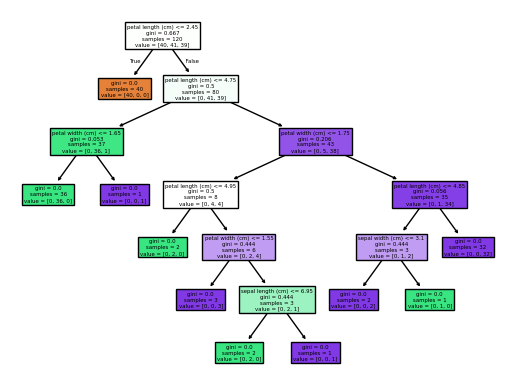

In [56]:
plot_tree(tree,filled=True,feature_names=X.columns)

In [57]:
tree2 = DecisionTreeClassifier(criterion='entropy',max_depth=3,random_state=42)

In [58]:
tree2.fit(X_train,y_train)
y_pred = tree2.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

[Text(0.375, 0.875, 'x[2] <= 2.45\nentropy = 1.585\nsamples = 120\nvalue = [40, 41, 39]'),
 Text(0.25, 0.625, 'entropy = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[2] <= 4.75\nentropy = 1.0\nsamples = 80\nvalue = [0, 41, 39]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[3] <= 1.65\nentropy = 0.179\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.125, 0.125, 'entropy = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.375, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.75, 0.375, 'x[3] <= 1.75\nentropy = 0.519\nsamples = 43\nvalue = [0, 5, 38]'),
 Text(0.625, 0.125, 'entropy = 1.0\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.875, 0.125, 'entropy = 0.187\nsamples = 35\nvalue = [0, 1, 34]')]

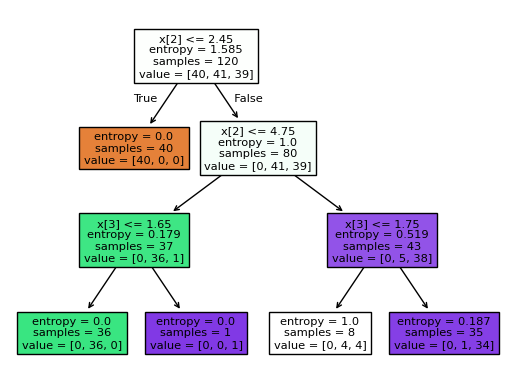

In [60]:
plot_tree(tree2,filled=True)

In [62]:
params = {'criterion':['gini','entropy'],
          'max_depth':[1,2,3,4,5,6]}

In [63]:
grid = GridSearchCV(estimator=DecisionTreeClassifier(),param_grid=params,scoring='accuracy',cv=5)

In [64]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6]},
             scoring='accuracy')

In [65]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 4}

In [66]:
bestest = grid.best_estimator_
bestest

DecisionTreeClassifier(max_depth=4)

In [68]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002222,0.001607,0.002175,0.000623,gini,1,"{'criterion': 'gini', 'max_depth': 1}",0.708333,0.666667,0.666667,0.666667,0.666667,0.675000,0.016667,11
1,0.001211,0.000223,0.001665,0.000494,gini,2,"{'criterion': 'gini', 'max_depth': 2}",0.958333,0.916667,0.833333,0.958333,0.916667,0.916667,0.045644,9
2,0.001243,0.000884,0.001460,0.000360,gini,3,"{'criterion': 'gini', 'max_depth': 3}",0.958333,1.000000,0.833333,0.958333,0.916667,0.933333,0.056519,3
3,0.001313,0.000522,0.001909,0.000500,gini,4,"{'criterion': 'gini', 'max_depth': 4}",0.958333,1.000000,0.833333,0.958333,0.958333,0.941667,0.056519,1
4,0.001330,0.000415,0.001496,0.000503,gini,5,"{'criterion': 'gini', 'max_depth': 5}",0.958333,1.000000,0.833333,0.958333,0.916667,0.933333,0.056519,3
5,0.001426,0.000380,0.001236,0.000226,gini,6,"{'criterion': 'gini', 'max_depth': 6}",0.958333,1.000000,0.833333,0.958333,0.958333,0.941667,0.056519,1
6,0.001427,0.000626,0.001457,0.000362,entropy,1,"{'criterion': 'entropy', 'max_depth': 1}",0.708333,0.666667,0.666667,0.666667,0.666667,0.675000,0.016667,11
7,0.001012,0.000555,0.001858,0.000649,entropy,2,"{'criterion': 'entropy', 'max_depth': 2}",0.958333,0.916667,0.833333,0.958333,0.916667,0.916667,0.045644,9
8,0.001113,0.000196,0.001825,0.000244,entropy,3,"{'criterion': 'entropy', 'max_depth': 3}",0.958333,1.000000,0.833333,0.958333,0.916667,0.933333,0.056519,3
9,0.001719,0.000549,0.001665,0.000592,entropy,4,"{'criterion': 'entropy', 'max_depth': 4}",0.958333,1.000000,0.833333,0.958333,0.916667,0.933333,0.056519,3
